In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dfM=pd.read_csv('Datos_limpios_Mexico.csv')
dfM.head()


,Unnamed: 0,last_scraped,source,name,description,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,reviews_per_month
0,0,25/09/2024,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...",Dici,28/06/2010,"Mexico City, Mexico","Master in visual arts, film photography & Mark...",a few days or more,...,0.0,4.80,4.90,4.80,4.90,4.90,4.90,4.70,1.0,1.20
1,1,26/09/2024,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,Fernando,09/08/2010,"Mexico City, Mexico",Condesa Haus offers independent studios and ...,within an hour,...,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,8.0,0.41
2,2,26/09/2024,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",Nicholas,04/01/2011,"Mexico City, Mexico","I am a journalist writing about food, (book an...",within an hour,...,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,2.0,0.31
3,3,25/09/2024,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Trisha,24/08/2010,"Mexico City, Mexico","I am a mother, documentary film maker and phot...",within a few hours,...,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,3.0,0.83
4,4,25/09/2024,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,Andrea,27/04/2011,"Mexico City, Mexico",I Leave in Mexico City... I am an Architect an...,within an hour,...,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,3.0,0.11


In [5]:
dfM=dfM.drop('Unnamed: 0',axis=1)
#dfB=dfB.drop( 'Unnamed: 0.1',axis=1)
dfB.head()
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26582 entries, 0 to 26581
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   last_scraped                    26582 non-null  object 
 1   source                          26582 non-null  object 
 2   name                            26582 non-null  object 
 3   description                     26582 non-null  object 
 4   host_name                       26582 non-null  object 
 5   host_since                      26582 non-null  object 
 6   host_location                   26582 non-null  object 
 7   host_about                      26582 non-null  object 
 8   host_response_time              26582 non-null  object 
 9   host_response_rate              26582 non-null  object 
 10  host_acceptance_rate            26582 non-null  object 
 11  host_is_superhost               26582 non-null  object 
 12  host_verifications              

In [20]:
hotel_room_dfM = dfM[dfM['room_type'] == 'Hotel room']
entire_home_dfM = dfM[dfM['room_type'] == 'Entire home/apt']
private_room_dfM = dfM[dfM['room_type'] == 'Private room']
shared_room_dfM = dfM[dfM['room_type'] == 'Shared room'] 

In [21]:
#eliminamos colunas que no nos interesan
hotel_room_dfM.drop(hotel_room_dfM.columns[[0,1,2,3,4,6,7,8,9,12,13,15,18,20,21,22,24,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
entire_home_dfM.drop(entire_home_dfM.columns[[0,1,2,3,4,6,7,8,9,12,13,15,18,20,21,22,24,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
private_room_dfM.drop(private_room_dfM.columns[[0,1,2,3,4,6,7,8,9,12,13,15,18,20,21,22,24,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
shared_room_dfM.drop(shared_room_dfM.columns[[0,1,2,3,4,6,7,8,9,12,13,15,18,20,21,22,24,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)

C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\1855534882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfM.drop(hotel_room_dfM.columns[[0,1,2,3,4,6,7,8,9,12,13,15,18,20,21,22,24,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\1855534882.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entire_home_dfM.drop(entire_home_dfM.columns[[0,1,2,3,4,6,7,8,9,12,13,15,18,20,21,22,24,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,47]], axis=1, inplace=True)
C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\1855534882.py:4: SettingWithCo

In [22]:
hotel_room_dfM['host_is_superhost'] = hotel_room_dfM['host_is_superhost'] == 't'

hotel_room_dfM.info()
hotel_room_dfM.head()


<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 48 to 24911
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_since                 125 non-null    object 
 1   host_acceptance_rate       125 non-null    object 
 2   host_is_superhost          125 non-null    bool   
 3   host_identity_verified     125 non-null    object 
 4   property_type              125 non-null    object 
 5   room_type                  125 non-null    object 
 6   has_availability           125 non-null    object 
 7   host_listings_count        125 non-null    float64
 8   accommodates               125 non-null    float64
 9   bathrooms                  125 non-null    float64
 10  bedrooms                   125 non-null    float64
 11  beds                       125 non-null    float64
 12  price                      125 non-null    float64
 13  review_scores_cleanliness  125 non-null    float64
 

C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\354980070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfM['host_is_superhost'] = hotel_room_dfM['host_is_superhost'] == 't'


,host_since,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,has_availability,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
48,09/08/2010,93%,True,t,Room in serviced apartment,Hotel room,t,12.0,3.0,1.0,1.0,1.0,999.0,5.00,4.86,0.06
62,01/06/2012,92%,True,t,Room in boutique hotel,Hotel room,t,8.0,2.0,1.0,1.0,1.0,999.0,5.00,4.93,0.21
75,01/06/2012,92%,True,t,Room in boutique hotel,Hotel room,t,8.0,2.0,1.0,1.0,1.0,999.0,4.97,4.86,0.45
100,09/08/2010,93%,True,t,Room in serviced apartment,Hotel room,t,12.0,3.0,1.0,1.0,1.0,1872.0,5.00,4.80,0.01
135,12/10/2012,89%,False,t,Room in serviced apartment,Hotel room,t,19.0,2.0,1.0,1.0,1.0,1275.0,4.84,4.80,0.18


In [23]:
Vars_Indep_hotel_room = hotel_room_dfM[['host_is_superhost']]  
Var_Dep_hotel_room = hotel_room_dfM['price']

<Axes: xlabel='host_is_superhost', ylabel='price'>

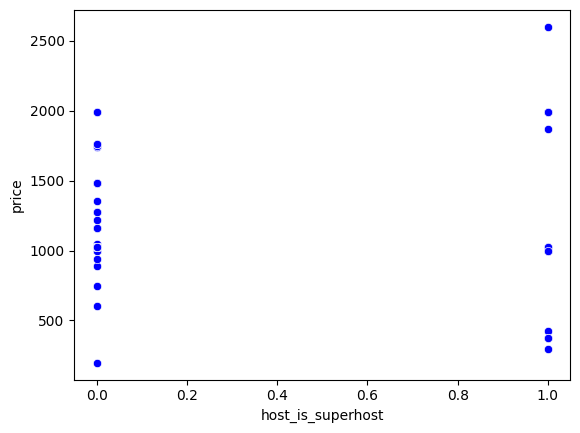

In [25]:
from turtle import color   
sns.scatterplot(x='host_is_superhost',y='price',color='blue',data=hotel_room_dfM)

In [26]:

#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model1= LinearRegression()

In [27]:
type(model1)

sklearn.linear_model._base.LinearRegression

In [28]:
model1.fit(X=Vars_Indep_hotel_room, y=Var_Dep_hotel_room)

LinearRegression()

In [29]:
model1.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([20.43424846]),
 'rank_': 1,
 'singular_': array([4.8282502]),
 'intercept_': np.float64(1106.5851063829784)}

In [30]:
model1.score(Vars_Indep_hotel_room,Var_Dep_hotel_room)


0.0006623779168015709

In [31]:
y_pred_hotel_room=model1.predict(X=hotel_room_dfM[['host_is_superhost']])
y_pred_hotel_room

array([1127.01935484, 1127.01935484, 1127.01935484, 1127.01935484,
       1106.58510638, 1106.58510638, 1106.58510638, 1106.58510638,
       1106.58510638, 1106.58510638, 1106.58510638, 1127.01935484,
       1106.58510638, 1106.58510638, 1127.01935484, 1106.58510638,
       1106.58510638, 1106.58510638, 1106.58510638, 1106.58510638,
       1106.58510638, 1127.01935484, 1106.58510638, 1127.01935484,
       1127.01935484, 1127.01935484, 1106.58510638, 1106.58510638,
       1127.01935484, 1127.01935484, 1127.01935484, 1127.01935484,
       1127.01935484, 1127.01935484, 1127.01935484, 1127.01935484,
       1127.01935484, 1127.01935484, 1127.01935484, 1127.01935484,
       1127.01935484, 1106.58510638, 1127.01935484, 1127.01935484,
       1106.58510638, 1127.01935484, 1106.58510638, 1106.58510638,
       1106.58510638, 1127.01935484, 1106.58510638, 1106.58510638,
       1106.58510638, 1106.58510638, 1127.01935484, 1106.58510638,
       1106.58510638, 1106.58510638, 1106.58510638, 1106.58510

In [32]:
hotel_room_dfM.insert(0,'predicciones_hotel_room',y_pred_hotel_room)
hotel_room_dfM

,predicciones_hotel_room,host_since,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,has_availability,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
48,1127.019355,09/08/2010,93%,True,t,Room in serviced apartment,Hotel room,t,12.0,3.0,1.0,1.0,1.0,999.0,5.00,4.86,0.06
62,1127.019355,01/06/2012,92%,True,t,Room in boutique hotel,Hotel room,t,8.0,2.0,1.0,1.0,1.0,999.0,5.00,4.93,0.21
75,1127.019355,01/06/2012,92%,True,t,Room in boutique hotel,Hotel room,t,8.0,2.0,1.0,1.0,1.0,999.0,4.97,4.86,0.45
100,1127.019355,09/08/2010,93%,True,t,Room in serviced apartment,Hotel room,t,12.0,3.0,1.0,1.0,1.0,1872.0,5.00,4.80,0.01
135,1106.585106,12/10/2012,89%,False,t,Room in serviced apartment,Hotel room,t,19.0,2.0,1.0,1.0,1.0,1275.0,4.84,4.80,0.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24907,1106.585106,20/11/2023,89%,False,f,Room in hotel,Hotel room,t,23.0,2.9,1.3,1.4,1.5,1026.3,4.80,4.70,1.20
24908,1106.585106,20/11/2023,89%,False,f,Room in hotel,Hotel room,t,23.0,2.9,1.3,1.4,1.5,1026.3,4.80,4.70,1.20
24909,1106.585106,20/11/2023,89%,False,f,Room in hotel,Hotel room,t,23.0,2.9,1.3,1.4,1.5,1026.3,4.80,4.70,1.20
24910,1106.585106,20/11/2023,89%,False,f,Room in hotel,Hotel room,t,23.0,2.0,1.0,1.0,1.0,1484.0,4.80,4.70,1.20


<Axes: xlabel='host_is_superhost', ylabel='price'>

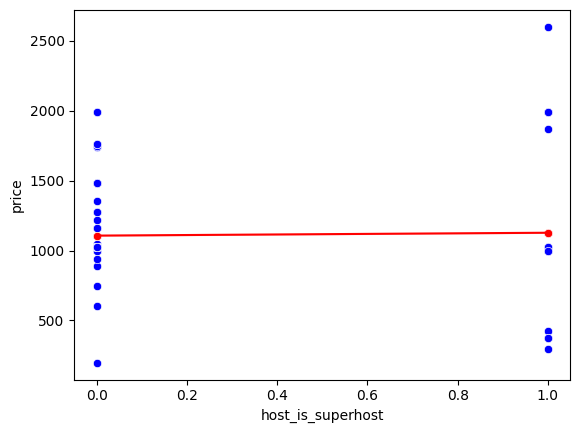

In [33]:
sns.scatterplot(x='host_is_superhost',y='price',color='blue',data=hotel_room_dfM)
sns.scatterplot(x='host_is_superhost',y='predicciones_hotel_room',color='red',data=hotel_room_dfM)
sns.lineplot(x='host_is_superhost',y='predicciones_hotel_room',color='red',data=hotel_room_dfM)

In [34]:
coef_Deter_hotel_room=model1.score(X=Vars_Indep_hotel_room, y=Var_Dep_hotel_room)
coef_Deter_hotel_room

0.0006623779168015709

In [35]:
coef_Correl_hotel_room=np.sqrt(coef_Deter_hotel_room)
coef_Correl_hotel_room

np.float64(0.025736703689508703)

In [ ]:
#hotel_room_dfB.host_is_superhost = hotel_room_dfB.host_response_rate.replace({'09/11/2024':'49.5'}, regex=False)

C:\Users\jesus\AppData\Local\Temp\ipykernel_1360\665962708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_room_dfB.host_response_rate = hotel_room_dfB.host_response_rate.replace({'09/11/2024':'49.5'}, regex=False)


In [37]:
import numpy as np

numeric_df_hotel_room = hotel_room_dfM.select_dtypes(include=[np.number])
Corr_Factors_hotel_room = numeric_df_hotel_room.corr()
print(Corr_Factors_hotel_room)

                           predicciones_hotel_room  host_listings_count  \
predicciones_hotel_room                   1.000000            -0.238858   
host_listings_count                      -0.238858             1.000000   
accommodates                             -0.050202             0.235359   
bathrooms                                -0.239691             0.373208   
bedrooms                                 -0.332363             0.316131   
beds                                     -0.276205             0.392083   
price                                     0.025737             0.125107   
review_scores_cleanliness                -0.187744            -0.247118   
review_scores_value                      -0.059945            -0.280860   
reviews_per_month                        -0.206566             0.304509   

                           accommodates  bathrooms  bedrooms      beds  \
predicciones_hotel_room       -0.050202  -0.239691 -0.332363 -0.276205   
host_listings_count       

In [38]:
Corr_Factors_hotel_room1=abs(Corr_Factors_hotel_room)
Corr_Factors_hotel_room1

,predicciones_hotel_room,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_hotel_room,1.000000,0.238858,0.050202,0.239691,0.332363,0.276205,0.025737,0.187744,0.059945,0.206566
host_listings_count,0.238858,1.000000,0.235359,0.373208,0.316131,0.392083,0.125107,0.247118,0.280860,0.304509
accommodates,0.050202,0.235359,1.000000,0.545088,0.547813,0.607516,0.065082,0.210763,0.150414,0.071554
bathrooms,0.239691,0.373208,0.545088,1.000000,0.897555,0.769013,0.124468,0.120543,0.233248,0.358182
bedrooms,0.332363,0.316131,0.547813,0.897555,1.000000,0.700731,0.297625,0.055239,0.052157,0.353655
beds,0.276205,0.392083,0.607516,0.769013,0.700731,1.000000,0.044820,0.103511,0.247014,0.368275
price,0.025737,0.125107,0.065082,0.124468,0.297625,0.044820,1.000000,0.106562,0.135453,0.127477
review_scores_cleanliness,0.187744,0.247118,0.210763,0.120543,0.055239,0.103511,0.106562,1.000000,0.586012,0.253192
review_scores_value,0.059945,0.280860,0.150414,0.233248,0.052157,0.247014,0.135453,0.586012,1.000000,0.319542
reviews_per_month,0.206566,0.304509,0.071554,0.358182,0.353655,0.368275,0.127477,0.253192,0.319542,1.000000


<Axes: >

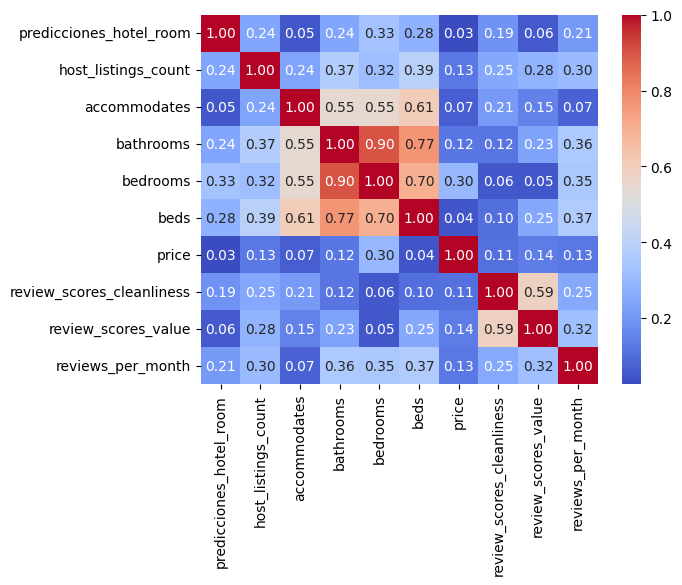

In [39]:
Heat_map=sns.heatmap(Corr_Factors_hotel_room1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

<Axes: xlabel='host_is_superhost', ylabel='price'>

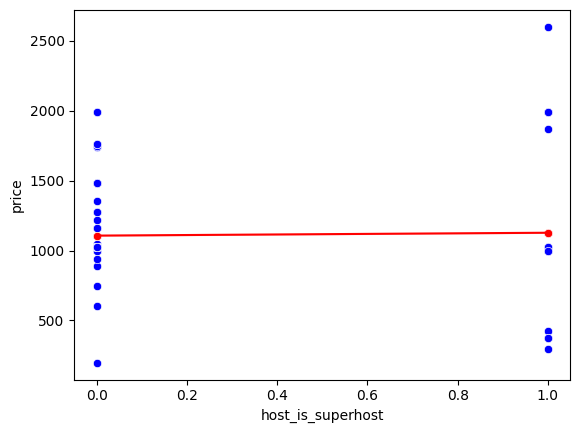

In [40]:

sns.scatterplot(x='host_is_superhost',y='price',color="blue",data=hotel_room_dfM)
sns.scatterplot(x='host_is_superhost',y='predicciones_hotel_room',color="red",data=hotel_room_dfM)
sns.lineplot(x='host_is_superhost',y='predicciones_hotel_room',color="red",data=hotel_room_dfM)


 ENTIRE HOME 

In [41]:
entire_home_dfM['host_is_superhost'] = entire_home_dfM['host_is_superhost'].map({'t': 1, 'f': 0})


C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\1512107820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entire_home_dfM['host_is_superhost'] = entire_home_dfM['host_is_superhost'].map({'t': 1, 'f': 0})


In [42]:
Vars_Indep_entire_home = entire_home_dfM[['host_is_superhost']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_entire_home = entire_home_dfM['price']

In [43]:
from sklearn.linear_model import LinearRegression
model2= LinearRegression()

In [44]:
type(model2)

sklearn.linear_model._base.LinearRegression

In [45]:
model2.fit(X=Vars_Indep_entire_home, y=Var_Dep_entire_home)

LinearRegression()

In [46]:
model2.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([57.1408425]),
 'rank_': 1,
 'singular_': array([65.07152175]),
 'intercept_': np.float64(1166.2979583706813)}

In [47]:
model2.score(Vars_Indep_entire_home,Var_Dep_entire_home)

0.0033495272373169627

In [49]:
y_pred_entire_home=model2.predict(X=entire_home_dfM[['host_is_superhost']])
y_pred_entire_home

array([1166.29795837, 1223.43880087, 1223.43880087, ..., 1166.29795837,
       1166.29795837, 1223.43880087], shape=(17363,))

In [50]:
entire_home_dfM.insert(0,'predicciones_entire_home',y_pred_entire_home)
entire_home_dfM


,predicciones_entire_home,host_since,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,has_availability,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
0,1166.297958,28/06/2010,89%,0,t,Entire villa,Entire home/apt,t,1.0,2.0,1.0,1.0,1.0,1026.3,4.80,4.70,1.20
1,1223.438801,09/08/2010,93%,1,t,Entire home,Entire home/apt,t,12.0,2.9,1.0,1.4,1.0,999.0,4.70,4.48,0.41
2,1223.438801,04/01/2011,57%,1,t,Entire rental unit,Entire home/apt,t,3.0,4.0,1.0,2.0,2.0,2029.0,4.75,4.91,0.31
3,1223.438801,24/08/2010,100%,1,t,Entire rental unit,Entire home/apt,t,3.0,2.0,1.0,1.0,1.0,1140.0,4.96,4.92,0.83
4,1223.438801,27/04/2011,100%,1,t,Entire loft,Entire home/apt,t,5.0,2.0,1.5,1.0,1.0,1026.3,5.00,4.82,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26572,1166.297958,22/09/2024,89%,0,t,Entire rental unit,Entire home/apt,t,1.0,4.0,1.0,3.0,3.0,700.0,4.80,4.70,1.20
26573,1166.297958,18/09/2024,89%,0,t,Entire condo,Entire home/apt,t,1.0,4.0,2.0,2.0,2.0,1900.0,4.80,4.70,1.20
26574,1166.297958,24/11/2020,89%,0,t,Entire rental unit,Entire home/apt,f,1.0,2.0,1.0,1.0,1.0,1200.0,4.80,4.70,1.20
26575,1166.297958,20/01/2019,100%,0,t,Entire rental unit,Entire home/apt,t,27.0,3.0,1.0,1.0,2.0,1358.0,4.80,4.70,1.20


<Axes: xlabel='host_is_superhost', ylabel='price'>

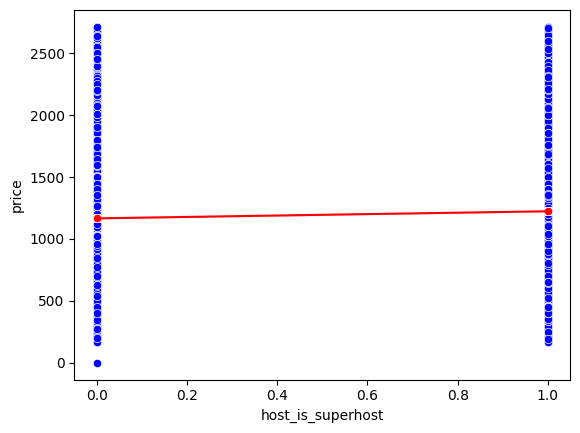

In [51]:

sns.scatterplot(x='host_is_superhost',y='price',color="blue",data=entire_home_dfM)
sns.scatterplot(x='host_is_superhost',y='predicciones_entire_home',color="red",data=entire_home_dfM)
sns.lineplot(x='host_is_superhost',y='predicciones_entire_home',color="red",data=entire_home_dfM)

In [52]:
coef_Deter_entire_home=model2.score(X=Vars_Indep_entire_home, y=Var_Dep_entire_home)
coef_Deter_entire_home

0.0033495272373169627

In [53]:
coef_Correl_entire_home=np.sqrt(coef_Deter_entire_home)
coef_Correl_entire_home

np.float64(0.05787510032230581)

In [54]:
import numpy as np

numeric_df_entire_home = entire_home_dfM.select_dtypes(include=[np.number])
Corr_Factors_entire_home = numeric_df_entire_home.corr()
print(Corr_Factors_entire_home)

                           predicciones_entire_home  host_is_superhost  \
predicciones_entire_home                   1.000000           1.000000   
host_is_superhost                          1.000000           1.000000   
host_listings_count                       -0.002232          -0.002232   
accommodates                               0.036360           0.036360   
bathrooms                                  0.060066           0.060066   
bedrooms                                   0.018484           0.018484   
beds                                       0.077272           0.077272   
price                                      0.057875           0.057875   
review_scores_cleanliness                  0.182897           0.182897   
review_scores_value                        0.175039           0.175039   
reviews_per_month                          0.228097           0.228097   

                           host_listings_count  accommodates  bathrooms  \
predicciones_entire_home            

In [ ]:
#Corr_Factors_entire_home=entire_home_dfB.corr()
#Corr_Factors_entire_home

In [55]:
Corr_Factors_entire_home1=abs(Corr_Factors_entire_home)
Corr_Factors_entire_home1

,predicciones_entire_home,host_is_superhost,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_entire_home,1.000000,1.000000,0.002232,0.036360,0.060066,0.018484,0.077272,0.057875,0.182897,0.175039,0.228097
host_is_superhost,1.000000,1.000000,0.002232,0.036360,0.060066,0.018484,0.077272,0.057875,0.182897,0.175039,0.228097
host_listings_count,0.002232,0.002232,1.000000,0.061552,0.019293,0.085404,0.054309,0.054738,0.047863,0.098161,0.059271
accommodates,0.036360,0.036360,0.061552,1.000000,0.417937,0.667785,0.546389,0.219952,0.001487,0.081181,0.058083
bathrooms,0.060066,0.060066,0.019293,0.417937,1.000000,0.539556,0.353445,0.330460,0.031789,0.082982,0.043748
bedrooms,0.018484,0.018484,0.085404,0.667785,0.539556,1.000000,0.461021,0.243499,0.004361,0.086164,0.004582
beds,0.077272,0.077272,0.054309,0.546389,0.353445,0.461021,1.000000,0.165677,0.005442,0.049565,0.080499
price,0.057875,0.057875,0.054738,0.219952,0.330460,0.243499,0.165677,1.000000,0.098472,0.076306,0.009947
review_scores_cleanliness,0.182897,0.182897,0.047863,0.001487,0.031789,0.004361,0.005442,0.098472,1.000000,0.539053,0.011101
review_scores_value,0.175039,0.175039,0.098161,0.081181,0.082982,0.086164,0.049565,0.076306,0.539053,1.000000,0.005689


<Axes: >

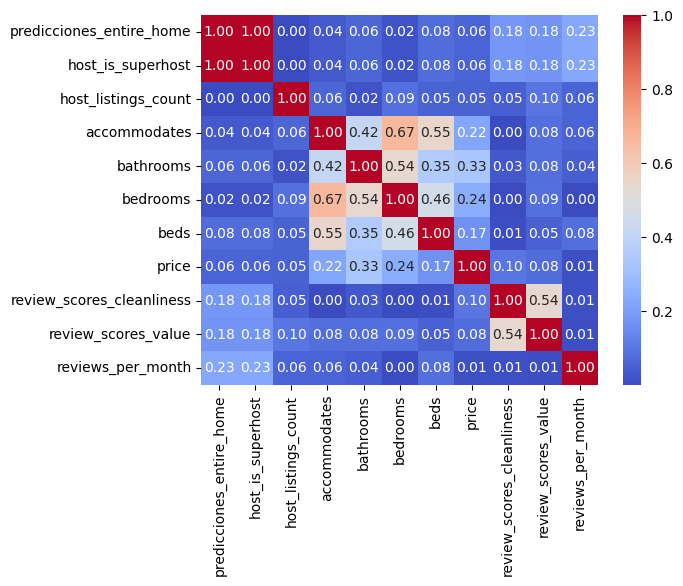

In [56]:
Heat_map=sns.heatmap(Corr_Factors_entire_home1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

PRIVATE ROOM 

In [58]:
private_room_dfM['host_is_superhost'] = private_room_dfM['host_is_superhost'].map({'t': 1, 'f': 0})


C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\227647614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  private_room_dfM['host_is_superhost'] = private_room_dfM['host_is_superhost'].map({'t': 1, 'f': 0})


In [59]:
Vars_Indep_private_room = private_room_dfM[['host_is_superhost']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_private_room = private_room_dfM['price']

In [60]:
from sklearn.linear_model import LinearRegression
model3= LinearRegression()

In [61]:
type(model3)

sklearn.linear_model._base.LinearRegression

In [62]:
model3.fit(X=Vars_Indep_private_room, y=Var_Dep_private_room)

LinearRegression()

In [63]:
model3.__dict__


{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-48.31813352]),
 'rank_': 1,
 'singular_': array([41.3199701]),
 'intercept_': np.float64(738.0973108979399)}

In [64]:
model3.score(Vars_Indep_private_room,Var_Dep_private_room)


0.0028426018069596104

In [65]:
y_pred_private_room=model3.predict(X=private_room_dfM[['host_is_superhost']])
y_pred_private_room

array([738.0973109 , 689.77917738, 689.77917738, ..., 738.0973109 ,
       738.0973109 , 738.0973109 ], shape=(8693,))

In [66]:
private_room_dfM.insert(0,'predicciones_private_room',y_pred_private_room)
private_room_dfM

,predicciones_private_room,host_since,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,has_availability,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
5,738.097311,31/05/2011,89%,0,f,Private room,Private room,f,3.0,2.0,1.0,2.0,1.0,999.0,4.80,4.70,1.20
7,689.779177,13/07/2011,78%,1,t,Private room in rental unit,Private room,t,2.0,2.0,1.0,1.0,1.0,335.0,4.61,4.81,0.84
10,689.779177,28/01/2012,100%,1,t,Private room in home,Private room,t,2.0,1.0,1.5,1.0,1.0,384.0,4.92,4.89,0.54
11,738.097311,10/10/2014,89%,0,f,Private room in condo,Private room,f,2.0,1.0,1.0,1.0,1.0,947.0,4.97,4.73,0.22
12,738.097311,10/04/2013,75%,0,t,Private room in guest suite,Private room,t,5.0,2.0,1.0,1.0,1.0,1200.0,4.97,4.94,1.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26576,738.097311,15/11/2023,89%,0,t,Private room in home,Private room,t,1.0,2.0,2.0,1.0,1.0,262.0,4.80,4.70,1.20
26577,689.779177,16/04/2016,100%,1,t,Private room in guesthouse,Private room,t,6.2,4.0,1.0,2.0,2.0,488.0,4.80,4.70,1.20
26578,738.097311,13/08/2024,100%,0,t,Room in hotel,Private room,t,16.0,2.0,1.0,1.0,1.0,1026.3,4.80,4.70,1.20
26579,738.097311,13/08/2024,100%,0,t,Room in hotel,Private room,t,16.0,2.0,1.0,1.0,1.0,2700.0,4.80,4.70,1.20


In [67]:
coef_Deter_private_room=model3.score(X=Vars_Indep_private_room, y=Var_Dep_private_room)
coef_Deter_private_room

0.0028426018069596104

In [68]:
coef_Correl_private_room=np.sqrt(coef_Deter_private_room)
coef_Correl_private_room

np.float64(0.05331605580835486)

In [69]:
import numpy as np

numeric_df_private_room = private_room_dfM.select_dtypes(include=[np.number])
Corr_Factors_private_room = numeric_df_private_room.corr()
print(Corr_Factors_private_room)

                           predicciones_private_room  host_is_superhost  \
predicciones_private_room                   1.000000          -1.000000   
host_is_superhost                          -1.000000           1.000000   
host_listings_count                         0.017201          -0.017201   
accommodates                                0.009647          -0.009647   
bathrooms                                   0.017499          -0.017499   
bedrooms                                    0.050317          -0.050317   
beds                                        0.006205          -0.006205   
price                                       0.053316          -0.053316   
review_scores_cleanliness                  -0.139424           0.139424   
review_scores_value                        -0.169317           0.169317   
reviews_per_month                          -0.234045           0.234045   

                           host_listings_count  accommodates  bathrooms  \
predicciones_private_roo

In [70]:
Corr_Factors_private_room1=abs(Corr_Factors_private_room)
Corr_Factors_private_room1

,predicciones_private_room,host_is_superhost,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_private_room,1.000000,1.000000,0.017201,0.009647,0.017499,0.050317,0.006205,0.053316,0.139424,0.169317,0.234045
host_is_superhost,1.000000,1.000000,0.017201,0.009647,0.017499,0.050317,0.006205,0.053316,0.139424,0.169317,0.234045
host_listings_count,0.017201,0.017201,1.000000,0.135178,0.041972,0.066299,0.013009,0.094855,0.123948,0.126255,0.081130
accommodates,0.009647,0.009647,0.135178,1.000000,0.072532,0.261402,0.430873,0.294480,0.026221,0.046936,0.065406
bathrooms,0.017499,0.017499,0.041972,0.072532,1.000000,0.138266,0.128685,0.096686,0.048275,0.017093,0.010218
bedrooms,0.050317,0.050317,0.066299,0.261402,0.138266,1.000000,0.263954,0.090213,0.016514,0.002961,0.057350
beds,0.006205,0.006205,0.013009,0.430873,0.128685,0.263954,1.000000,0.101172,0.008674,0.004906,0.019223
price,0.053316,0.053316,0.094855,0.294480,0.096686,0.090213,0.101172,1.000000,0.115561,0.021494,0.095983
review_scores_cleanliness,0.139424,0.139424,0.123948,0.026221,0.048275,0.016514,0.008674,0.115561,1.000000,0.554235,0.138847
review_scores_value,0.169317,0.169317,0.126255,0.046936,0.017093,0.002961,0.004906,0.021494,0.554235,1.000000,0.133081


<Axes: >

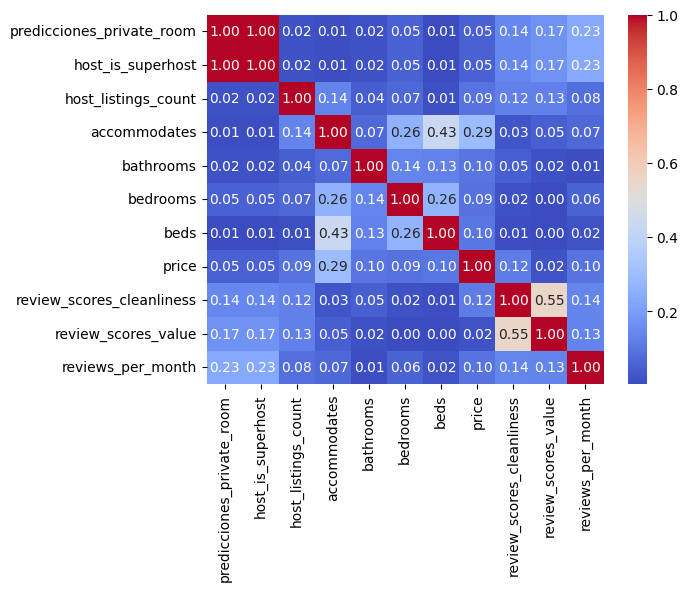

In [71]:
Heat_map=sns.heatmap(Corr_Factors_private_room1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

<Axes: xlabel='host_is_superhost', ylabel='price'>

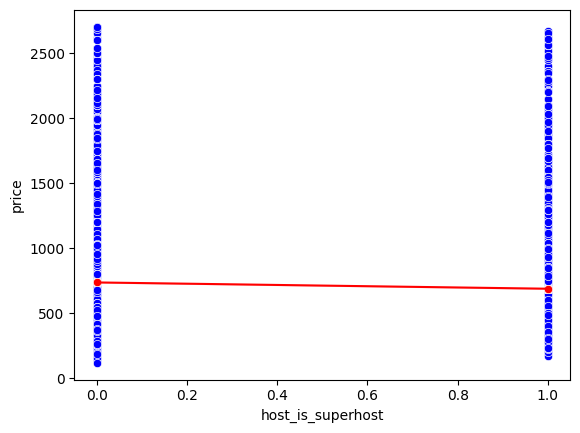

In [72]:
sns.scatterplot(x='host_is_superhost',y='price',color="blue",data=private_room_dfM)
sns.scatterplot(x='host_is_superhost',y='predicciones_private_room',color="red",data=private_room_dfM)
sns.lineplot(x='host_is_superhost',y='predicciones_private_room',color="red",data=private_room_dfM)

SHARED ROOM

In [73]:
shared_room_dfM['host_is_superhost'] =shared_room_dfM['host_is_superhost'].map({'t': 1, 'f': 0})


C:\Users\jesus\AppData\Local\Temp\ipykernel_11240\2240339177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_room_dfM['host_is_superhost'] =shared_room_dfM['host_is_superhost'].map({'t': 1, 'f': 0})


In [74]:
Vars_Indep_shared_room = shared_room_dfM[['host_is_superhost']]  # Asumiendo que solo quieres analizar 'host_response_rate'
Var_Dep_shared_room = shared_room_dfM['price']

In [75]:
from sklearn.linear_model import LinearRegression
model4= LinearRegression()

In [76]:
type(model4)

sklearn.linear_model._base.LinearRegression

In [77]:
model4.fit(X=Vars_Indep_shared_room, y=Var_Dep_shared_room)

LinearRegression()

In [78]:
model4.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_is_superhost'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([-79.12811634]),
 'rank_': 1,
 'singular_': array([6.0008312]),
 'intercept_': np.float64(431.47811634349034)}

In [79]:
model4.score(Vars_Indep_shared_room,Var_Dep_shared_room)

0.004626206742887939

In [81]:
y_pred_shared_room=model4.predict(X=shared_room_dfM[['host_is_superhost']])
y_pred_shared_room

array([431.47811634, 431.47811634, 352.35      , 431.47811634,
       352.35      , 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47811634,
       431.47811634, 431.47811634, 431.47811634, 431.47

In [82]:
shared_room_dfM.insert(0,'predicciones_shared_room',y_pred_shared_room)
shared_room_dfM

,predicciones_shared_room,host_since,host_acceptance_rate,host_is_superhost,host_identity_verified,property_type,room_type,has_availability,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
115,431.478116,26/07/2012,89%,0,f,Shared room in rental unit,Shared room,f,1.0,2.0,1.0,1.0,1.0,999.0,4.80,4.70,1.20
258,431.478116,30/05/2014,0%,0,t,Shared room in loft,Shared room,t,3.0,1.0,1.5,2.0,2.0,640.0,4.80,4.70,1.20
366,352.350000,22/02/2015,85%,1,t,Shared room in guesthouse,Shared room,t,2.0,2.9,1.3,1.0,1.5,290.0,4.47,4.59,0.30
444,431.478116,09/06/2015,31%,0,t,Shared room in hostel,Shared room,t,6.2,2.9,1.3,1.0,1.5,1026.3,4.80,4.70,1.20
456,352.350000,17/04/2015,94%,1,t,Shared room in home,Shared room,t,2.0,2.9,3.0,1.0,1.5,550.0,4.93,4.93,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26261,431.478116,19/03/2016,100%,0,t,Shared room in home,Shared room,t,4.0,6.0,1.0,1.0,1.5,1200.0,4.80,4.70,1.20
26336,431.478116,19/02/2019,100%,0,t,Shared room in rental unit,Shared room,t,32.0,2.0,1.0,1.0,0.0,70.0,4.80,4.70,1.20
26371,431.478116,19/02/2019,100%,0,t,Shared room in rental unit,Shared room,t,32.0,2.0,1.0,1.0,0.0,70.0,4.80,4.70,1.20
26447,431.478116,17/09/2024,89%,0,t,Shared room in guesthouse,Shared room,t,4.0,2.9,2.5,1.4,1.5,1058.0,5.00,5.00,1.00


In [83]:
coef_Deter_shared_room=model4.score(X=Vars_Indep_shared_room, y=Var_Dep_shared_room)
coef_Deter_shared_room


0.004626206742887939

In [84]:
coef_Correl_shared_room=np.sqrt(coef_Deter_shared_room)
coef_Correl_shared_room

np.float64(0.06801622411519137)

In [86]:
import numpy as np

numeric_df_shared_room = hotel_room_dfM.select_dtypes(include=[np.number])
Corr_Factors_shared_room = numeric_df_shared_room.corr()
print(Corr_Factors_hotel_room)


                           predicciones_hotel_room  host_listings_count  \
predicciones_hotel_room                   1.000000            -0.238858   
host_listings_count                      -0.238858             1.000000   
accommodates                             -0.050202             0.235359   
bathrooms                                -0.239691             0.373208   
bedrooms                                 -0.332363             0.316131   
beds                                     -0.276205             0.392083   
price                                     0.025737             0.125107   
review_scores_cleanliness                -0.187744            -0.247118   
review_scores_value                      -0.059945            -0.280860   
reviews_per_month                        -0.206566             0.304509   

                           accommodates  bathrooms  bedrooms      beds  \
predicciones_hotel_room       -0.050202  -0.239691 -0.332363 -0.276205   
host_listings_count       

In [87]:

Corr_Factors_shared_room1=abs(Corr_Factors_shared_room)
Corr_Factors_shared_room1

,predicciones_hotel_room,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,review_scores_cleanliness,review_scores_value,reviews_per_month
predicciones_hotel_room,1.000000,0.238858,0.050202,0.239691,0.332363,0.276205,0.025737,0.187744,0.059945,0.206566
host_listings_count,0.238858,1.000000,0.235359,0.373208,0.316131,0.392083,0.125107,0.247118,0.280860,0.304509
accommodates,0.050202,0.235359,1.000000,0.545088,0.547813,0.607516,0.065082,0.210763,0.150414,0.071554
bathrooms,0.239691,0.373208,0.545088,1.000000,0.897555,0.769013,0.124468,0.120543,0.233248,0.358182
bedrooms,0.332363,0.316131,0.547813,0.897555,1.000000,0.700731,0.297625,0.055239,0.052157,0.353655
beds,0.276205,0.392083,0.607516,0.769013,0.700731,1.000000,0.044820,0.103511,0.247014,0.368275
price,0.025737,0.125107,0.065082,0.124468,0.297625,0.044820,1.000000,0.106562,0.135453,0.127477
review_scores_cleanliness,0.187744,0.247118,0.210763,0.120543,0.055239,0.103511,0.106562,1.000000,0.586012,0.253192
review_scores_value,0.059945,0.280860,0.150414,0.233248,0.052157,0.247014,0.135453,0.586012,1.000000,0.319542
reviews_per_month,0.206566,0.304509,0.071554,0.358182,0.353655,0.368275,0.127477,0.253192,0.319542,1.000000


<Axes: xlabel='host_is_superhost', ylabel='price'>

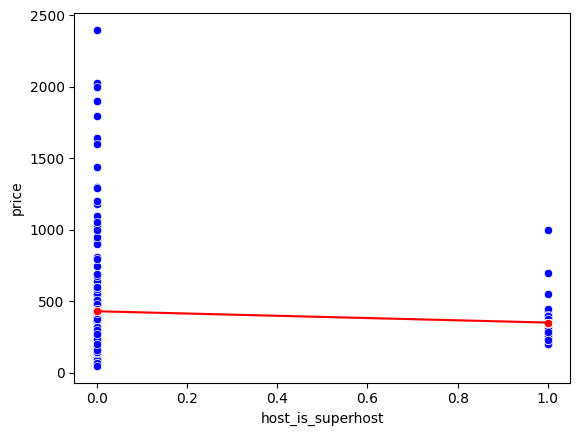

In [88]:
sns.scatterplot(x='host_is_superhost',y='price',color="blue",data=shared_room_dfM)
sns.scatterplot(x='host_is_superhost',y='predicciones_shared_room',color="red",data=shared_room_dfM)
sns.lineplot(x='host_is_superhost',y='predicciones_shared_room',color="red",data=shared_room_dfM)

<Axes: >

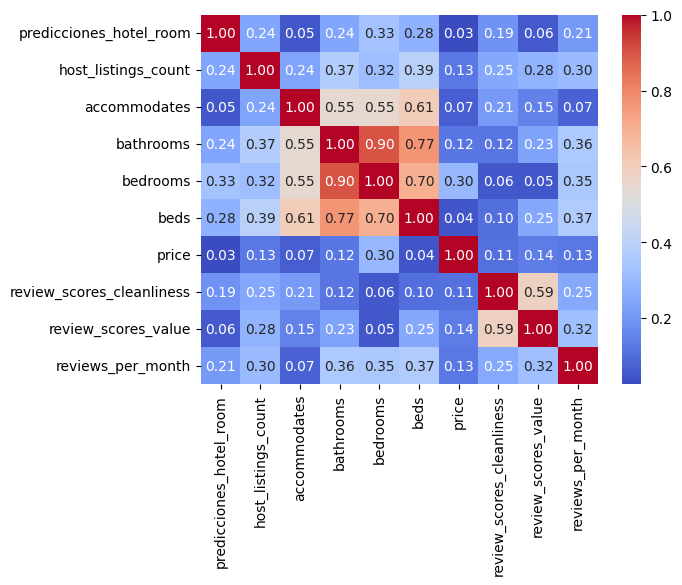

In [89]:
Heat_map=sns.heatmap(Corr_Factors_shared_room1,cmap='coolwarm',annot=True,fmt='.2f')
Heat_map

<Axes: xlabel='room_type', ylabel='price'>

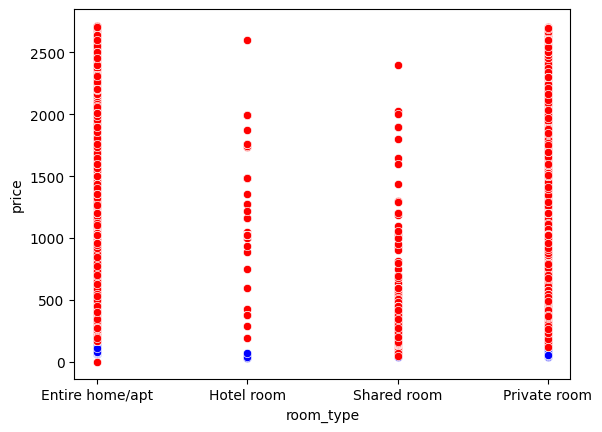

In [ ]:
#comparadno mexico con bozeman
sns.scatterplot(x='room_type', y='price', color='blue', data=dfB)
sns.scatterplot(x='room_type', y='price', color='red', data=dfM)